In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv('dataset2.csv')

In [2]:
import pandas as pd

# Create price bins (range = 25)
bins = range(0, int(df['final_price_usd'].max()) + 25, 25)

df['price_range'] = pd.cut(df['final_price_usd'], bins=bins)

C:\Users\dell\AppData\Local\Temp\ipykernel_20960\3880940121.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  units_grouped = df.groupby('price_range')['units_sold'].sum().reset_index()



📊 Units Sold by Price Range:

  price_range  units_sold
0     (0, 25]           0
1    (25, 50]        1188
2    (50, 75]       11973
3   (75, 100]       13837
4  (100, 125]       13621
5  (125, 150]       13614
6  (150, 175]       11503
7  (175, 200]        7057
8  (200, 225]        2213


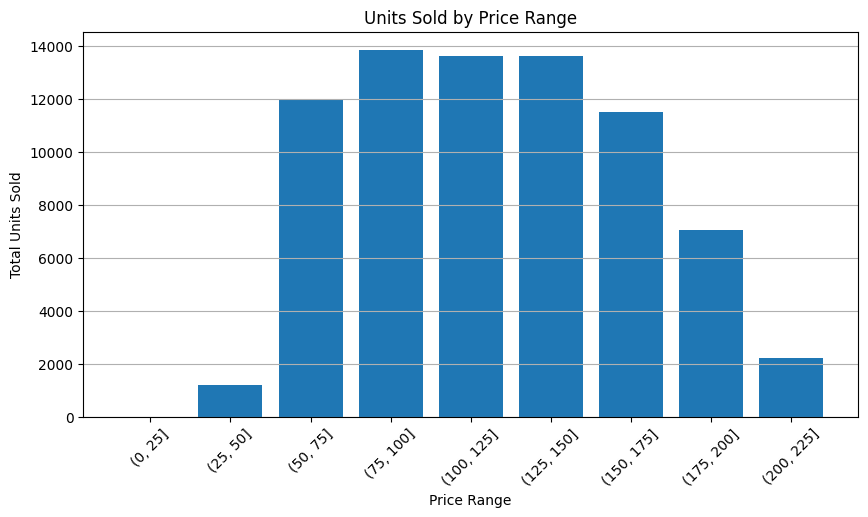

In [3]:
import matplotlib.pyplot as plt

# Group
units_grouped = df.groupby('price_range')['units_sold'].sum().reset_index()

# Sort
units_grouped = units_grouped.sort_values(by='price_range')

# Print
print("\n📊 Units Sold by Price Range:\n")
print(units_grouped)

# Plot
plt.figure(figsize=(10,5))
plt.bar(units_grouped['price_range'].astype(str), units_grouped['units_sold'])

plt.xlabel('Price Range')
plt.ylabel('Total Units Sold')
plt.title('Units Sold by Price Range')

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20960\2552981439.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_grouped = df.groupby('price_range')['order_id'].count().reset_index()



📊 Number of Orders by Price Range:

  price_range  order_id
0     (0, 25]         0
1    (25, 50]       468
2    (50, 75]      4770
3   (75, 100]      5589
4  (100, 125]      5425
5  (125, 150]      5481
6  (150, 175]      4560
7  (175, 200]      2818
8  (200, 225]       889


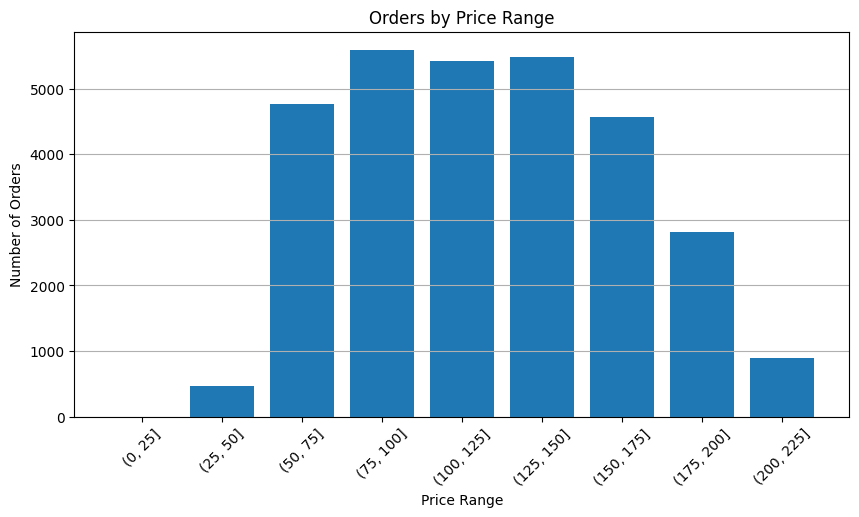

In [4]:
# Group
orders_grouped = df.groupby('price_range')['order_id'].count().reset_index()

# Sort
orders_grouped = orders_grouped.sort_values(by='price_range')

# Print
print("\n📊 Number of Orders by Price Range:\n")
print(orders_grouped)

# Plot
plt.figure(figsize=(10,5))
plt.bar(orders_grouped['price_range'].astype(str), orders_grouped['order_id'])

plt.xlabel('Price Range')
plt.ylabel('Number of Orders')
plt.title('Orders by Price Range')

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20960\1384520041.py:9: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
C:\Users\dell\AppData\Local\Temp\ipykernel_20960\1384520041.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['year', 'price_range'])['order_id']
C:\Users\dell\AppData\Local\Temp\ipykernel_20960\1384520041.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  year_price_orders.groupby('price_range')['or


📊 Avg Number of Orders by Price Range:

  price_range  avg_orders
0     (0, 25]    0.000000
1    (25, 50]   52.000000
2    (50, 75]  530.000000
3   (75, 100]  621.000000
4  (100, 125]  602.777778
5  (125, 150]  609.000000
6  (150, 175]  506.666667
7  (175, 200]  313.111111
8  (200, 225]   98.777778


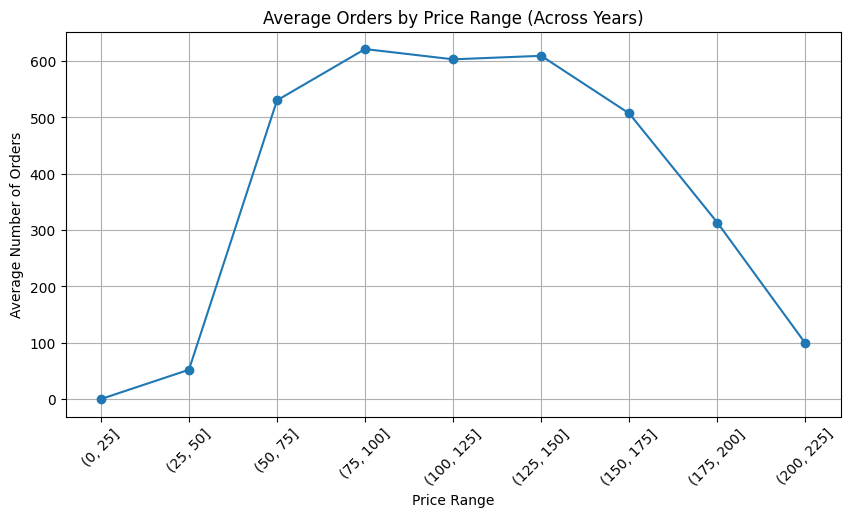

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Price bins
bins = range(0, int(df['final_price_usd'].max()) + 25, 25)
df['price_range'] = pd.cut(df['final_price_usd'], bins=bins)

# 2) Year
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year

# 3) Orders per (year, price_range)
year_price_orders = (
    df.groupby(['year', 'price_range'])['order_id']
      .count()
      .reset_index(name='orders')
)

# 4) Average orders across years (per price range)
avg_orders = (
    year_price_orders.groupby('price_range')['orders']
    .mean()
    .reset_index(name='avg_orders')
    .sort_values(by='price_range')
)

# 5) Output
print("\n📊 Avg Number of Orders by Price Range:\n")
print(avg_orders)

# 6) Plot
plt.figure(figsize=(10,5))
plt.plot(avg_orders['price_range'].astype(str), avg_orders['avg_orders'], marker='o')

plt.xlabel('Price Range')
plt.ylabel('Average Number of Orders')
plt.title('Average Orders by Price Range (Across Years)')

plt.xticks(rotation=45)
plt.grid()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20960\2442410088.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_count = df.groupby('price_range')['model_name'].nunique().reset_index()



📊 Unique Products in Each Price Range:

  price_range  unique_products
0     (0, 25]                0
1    (25, 50]              361
2    (50, 75]              890
3   (75, 100]              898
4  (100, 125]              896
5  (125, 150]              899
6  (150, 175]              892
7  (175, 200]              859
8  (200, 225]              572


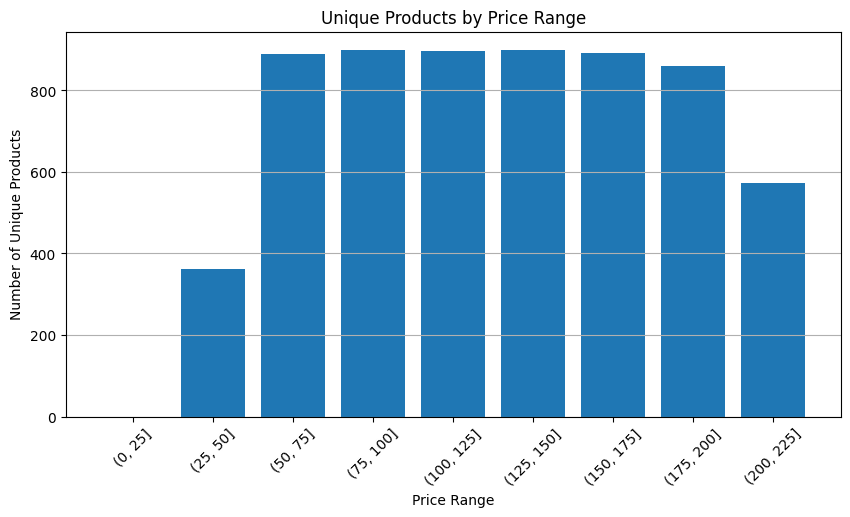

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create price bins (if not already)
bins = range(0, int(df['final_price_usd'].max()) + 25, 25)
df['price_range'] = pd.cut(df['final_price_usd'], bins=bins)

# Step 2: Count unique products (model_name)
product_count = df.groupby('price_range')['model_name'].nunique().reset_index()

# Step 3: Rename column
product_count.rename(columns={'model_name': 'unique_products'}, inplace=True)

# Step 4: Sort
product_count = product_count.sort_values(by='price_range')

# Step 5: Print
print("\n📊 Unique Products in Each Price Range:\n")
print(product_count)

# Step 6: Plot
plt.figure(figsize=(10,5))

plt.bar(product_count['price_range'].astype(str), product_count['unique_products'])

plt.xlabel('Price Range')
plt.ylabel('Number of Unique Products')
plt.title('Unique Products by Price Range')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_20960\2481868283.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_per_range = df.groupby('price_range')['order_id'].count().reset_index()



📊 Number of Orders per Price Range:

  price_range  order_count
0     (0, 25]            0
1    (25, 50]          468
2    (50, 75]         4770
3   (75, 100]         5589
4  (100, 125]         5425
5  (125, 150]         5481
6  (150, 175]         4560
7  (175, 200]         2818
8  (200, 225]          889


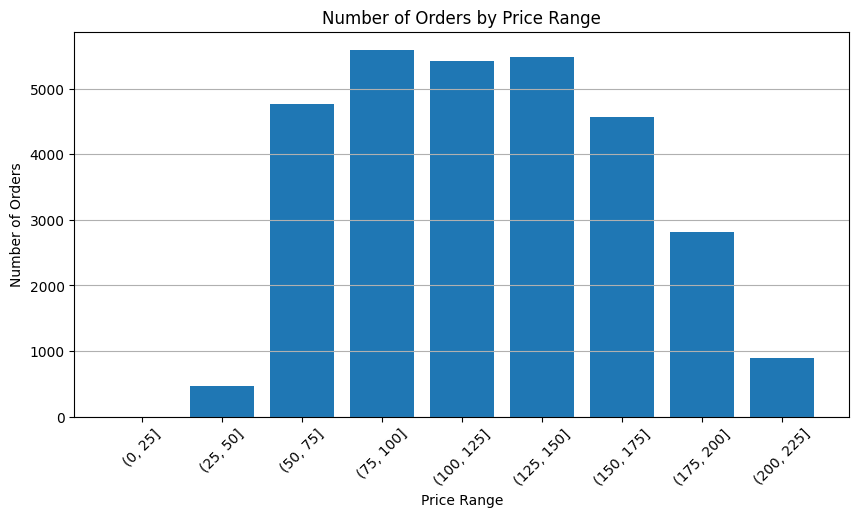

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create price bins (if not already)
bins = range(0, int(df['final_price_usd'].max()) + 25, 25)
df['price_range'] = pd.cut(df['final_price_usd'], bins=bins)

# Step 2: Count number of orders
orders_per_range = df.groupby('price_range')['order_id'].count().reset_index()

# Step 3: Rename column
orders_per_range.rename(columns={'order_id': 'order_count'}, inplace=True)

# Step 4: Sort
orders_per_range = orders_per_range.sort_values(by='price_range')

# Step 5: Print
print("\n📊 Number of Orders per Price Range:\n")
print(orders_per_range)

# Step 6: Plot
plt.figure(figsize=(10,5))

plt.bar(orders_per_range['price_range'].astype(str), orders_per_range['order_count'])

plt.xlabel('Price Range')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Price Range')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [8]:
from scipy.stats import f_oneway

# Step 1: Create price groups
def price_group(p):
    if p < 75:
        return 'Low'
    elif p <= 150:
        return 'Mid'
    else:
        return 'High'

df['price_group'] = df['final_price_usd'].apply(price_group)

# Step 2: Count orders per (year, price_group)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year

grouped = df.groupby(['year', 'price_group'])['order_id'].count().reset_index()

# Step 3: Separate groups (NOW NUMERIC ✅)
low = grouped[grouped['price_group'] == 'Low']['order_id']
mid = grouped[grouped['price_group'] == 'Mid']['order_id']
high = grouped[grouped['price_group'] == 'High']['order_id']

# Step 4: ANOVA
f_stat, p_value = f_oneway(low, mid, high)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 3526.5925868607633
P-value: 2.313173414736167e-30


In [9]:
from scipy.stats import ttest_ind

# Mid vs Low
t1, p1 = ttest_ind(mid, low, alternative='greater')

# Mid vs High
t2, p2 = ttest_ind(mid, high, alternative='greater')

print("Mid > Low p-value:", p1)
print("Mid > High p-value:", p2)

Mid > Low p-value: 2.324532103949779e-22
Mid > High p-value: 1.0655373902160018e-19


In [10]:
import pandas as pd
from scipy.stats import f_oneway, ttest_ind

# ================================
# STEP 1: Create Price Groups
# ================================
def price_group(p):
    if p < 75:
        return 'Low'
    elif p <= 150:
        return 'Mid'
    else:
        return 'High'

df['price_group'] = df['final_price_usd'].apply(price_group)

# ================================
# STEP 2: Extract Year
# ================================
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year

# ================================
# STEP 3: Aggregate Orders (IMPORTANT)
# ================================
# Count number of orders per (year, price_group)
grouped = df.groupby(['year', 'price_group'])['order_id'].count().reset_index()

# ================================
# STEP 4: Prepare Data for Testing
# ================================
low = grouped[grouped['price_group'] == 'Low']['order_id']
mid = grouped[grouped['price_group'] == 'Mid']['order_id']
high = grouped[grouped['price_group'] == 'High']['order_id']

# ================================
# STEP 5: ANOVA TEST
# ================================
# H0: No difference in orders across price groups
# H1: At least one group is different

f_stat, p_anova = f_oneway(low, mid, high)

print("===== ANOVA RESULT =====")
print("F-statistic:", f_stat)
print("P-value:", p_anova)

alpha = 0.05

if p_anova < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("➡ There is a significant difference in orders across price groups")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("➡ No significant difference between price groups")

# ================================
# STEP 6: POST-HOC T-TESTS
# ================================
# Now check if Mid group is significantly higher

# H0: Mid <= Low
# H1: Mid > Low
t1, p1 = ttest_ind(mid, low, alternative='greater')

# H0: Mid <= High
# H1: Mid > High
t2, p2 = ttest_ind(mid, high, alternative='greater')

print("\n===== POST-HOC T-TEST RESULTS =====")

print("\nMid vs Low p-value:", p1)
if p1 < alpha:
    print("Reject H0 → Mid has significantly MORE orders than Low")
else:
    print("Fail to Reject H0 → No significant difference")

print("\nMid vs High p-value:", p2)
if p2 < alpha:
    print("Reject H0 → Mid has significantly MORE orders than High")
else:
    print("Fail to Reject H0 → No significant difference")

# ================================
# STEP 7: FINAL CONCLUSION
# ================================
if p_anova < alpha and p1 < alpha and p2 < alpha:
    print("\n===== FINAL CONCLUSION =====")
    print("✔ Inverted U-shaped relationship confirmed")
    print("➡ Mid-price range (75–150 USD) has highest demand")
else:
    print("\n===== FINAL CONCLUSION =====")
    print("❌ Inverted U-shape not fully supported")

===== ANOVA RESULT =====
F-statistic: 3526.5925868607633
P-value: 2.313173414736167e-30

Reject Null Hypothesis (H0)
➡ There is a significant difference in orders across price groups

===== POST-HOC T-TEST RESULTS =====

Mid vs Low p-value: 2.324532103949779e-22
Reject H0 → Mid has significantly MORE orders than Low

Mid vs High p-value: 1.0655373902160018e-19
Reject H0 → Mid has significantly MORE orders than High

===== FINAL CONCLUSION =====
✔ Inverted U-shaped relationship confirmed
➡ Mid-price range (75–150 USD) has highest demand


In [11]:
price_summary = df.groupby("price_category").agg({
    "units_sold": "sum",
    "revenue_usd": "sum",
    "order_id": "count"
}).rename(columns={"order_id": "num_orders"})

print(price_summary)

                units_sold  revenue_usd  num_orders
price_category                                     
High                 20773   3640260.30        8267
Low                  13161    820647.10        5238
Mid                  41072   4620541.05       16495


In [14]:
bins = [-1, 10, 20, float('inf')]
labels = ["Low", "Mid", "High"]

df["discount_category"] = pd.cut(df["discount_percent"], bins=bins, labels=labels)

pivot = df.pivot_table(
    values="revenue_usd",
    index="price_category",
    columns="discount_category",
    aggfunc="mean"
)

print(pivot)

discount_category         Low         Mid        High
price_category                                       
High               449.931740  418.801730  403.860000
Low                164.379014  155.703913  148.591678
Mid                280.023529  279.651083  281.111118


C:\Users\dell\AppData\Local\Temp\ipykernel_20960\108400011.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


In [13]:
inventory = df.groupby(["category", "price_category"])["units_sold"].sum().sort_values(ascending=False)

print(inventory)

category    price_category
Training    Mid               8435
Lifestyle   Mid               8252
Gym         Mid               8166
Basketball  Mid               8121
Running     Mid               8098
Lifestyle   High              4256
Training    High              4210
Basketball  High              4182
Running     High              4126
Gym         High              3999
Basketball  Low               2857
Running     Low               2704
Lifestyle   Low               2621
Training    Low               2497
Gym         Low               2482
Name: units_sold, dtype: int64
